# 2024 Tip of the Tongue Track

The project works with the TREC 2024 Tip of the Tongue dataset.

https://pages.nist.gov/trec-browser/trec33/tot/data/

The dataset for the 2024 Tip-of-the-Tongue task contains queries, a shared corpus, and qrels. The queries are in JSONL format, qrels are in TXT format, and the documents are obtained from the official ToT corpus via ir_datasets. We need to perform a retrieval task where we have to retrieve the correct target document from the shared corpus for the query.


In [ ]:
# data loading: TREC 2024 Tip-of-the-Tongue
!pip install -U ir_datasets

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 98.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 58.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 236.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.2 kB/s eta 0:00:00
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=b2a7e4057db33afa15d7ab65afbb4bdea6333d620cef62e542581c52a5f8a5be
  Stored in directory: /root/.cache/pip/wheels/f6/85/c2/9f0f621def52a1d5db7d29984f81e45f9fb6dfeb1a4eb6e31c
  Created wheel for cbor: filename=cbor-1.0.0-cp312-cp312-linux_x86_64.whl size=55022 sha256=825bb7dd833547c42de7c7895ebb8d7c467b8ea18e39592da7fd95c1610591bd
  Stored in directory: /root/.cache/pip/wheels/44/3e/21/a739cbcc331a1ab45c326d6edbdac6118de4402f6076e30ff1
Successfully built warc3-wet-clueweb09 cbor


In [ ]:
# import libraries
from google.colab import drive
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ir_datasets
import os
from itertools import islice
import glob
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
import urllib.request
import zipfile
import warnings
from IPython.utils import io
import random
import torch

# for reproducibility
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_reproducibility(42)

In [ ]:
# loading corpus
corpus_2024=ir_datasets.load("trec-tot/2024")
print(corpus_2024)

# create folder inside colab
os.makedirs("reports/figures", exist_ok=True)

Dataset(id='trec-tot/2024', provides=['docs'])


In [ ]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/unzipped", exist_ok=True)

files = {
    "train": "https://zenodo.org/records/13370657/files/train-2024.zip?download=1",
    "dev1":  "https://zenodo.org/records/13370657/files/dev1-2024.zip?download=1",
    "dev2":  "https://zenodo.org/records/13370657/files/dev2-2024.zip?download=1",
}

for name, url in files.items():
    zip_path = f"data/raw/{name}.zip"

    if not os.path.exists(zip_path):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, zip_path)
    else:
        print(f"{name} already exists.")

    # unzip
    extract_path = f"data/unzipped/{name}"
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Download + unzip completed")

# dev1 validation set
# dev2 test set

Download + unzip completed


In [ ]:
# this block searches for query and qrel files inside the train and dev

# locate training queries
train_query_list = glob.glob("data/unzipped/train/**/*.jsonl", recursive=True)
train_qrel_list  = glob.glob("data/unzipped/train/**/qrel.txt", recursive=True)

# locate validation queries
val_query_list = glob.glob("data/unzipped/dev1/**/*.jsonl", recursive=True)
val_qrel_list  = glob.glob("data/unzipped/dev1/**/qrel.txt", recursive=True)

# locate test queries
test_query_list = glob.glob("data/unzipped/dev2/**/*.jsonl", recursive=True)
test_qrel_list  = glob.glob("data/unzipped/dev2/**/qrel.txt", recursive=True)

print("train query candidates:", train_query_list)
print("train qrel candidates :", train_qrel_list)
print("val query candidates  :", val_query_list)
print("val qrel candidates   :", val_qrel_list)
print("test query candidates :", test_query_list)
print("test qrel candidates  :", test_qrel_list)

train_query_path = train_query_list[0]
train_qrel_path  = train_qrel_list[0]

val_query_path = val_query_list[0]
val_qrel_path  = val_qrel_list[0]

test_query_path = test_query_list[0]
test_qrel_path  = test_qrel_list[0]

print("Train query path:", train_query_path)
print("Train qrel path :", train_qrel_path)
print("Validation query path:", val_query_path)
print("Validation qrel path :", val_qrel_path)
print("Test query path :", test_query_path)
print("Test qrel path  :", test_qrel_path)

train query candidates: ['data/unzipped/train/train-2024/queries.jsonl']
train qrel candidates : ['data/unzipped/train/train-2024/qrel.txt']
val query candidates  : ['data/unzipped/dev1/dev1-2024/queries.jsonl']
val qrel candidates   : ['data/unzipped/dev1/dev1-2024/qrel.txt']
test query candidates : ['data/unzipped/dev2/dev2-2024/queries.jsonl']
test qrel candidates  : ['data/unzipped/dev2/dev2-2024/qrel.txt']
Train query path: data/unzipped/train/train-2024/queries.jsonl
Train qrel path : data/unzipped/train/train-2024/qrel.txt
Validation query path: data/unzipped/dev1/dev1-2024/queries.jsonl
Validation qrel path : data/unzipped/dev1/dev1-2024/qrel.txt
Test query path : data/unzipped/dev2/dev2-2024/queries.jsonl
Test qrel path  : data/unzipped/dev2/dev2-2024/qrel.txt


In [ ]:
# loading query datasets for train and dev splits
# this query represents a user information retrieval
queries_train_2024 = pd.read_json(train_query_path, lines=True)
queries_val_2024  = pd.read_json(val_query_path, lines=True)
queries_test_2024  = pd.read_json(test_query_path, lines=True)

# both cases have 150 queries and 2 columns (query_id, query)
print("Train queries shape:", queries_train_2024.shape)
print("Validation queries shape :", queries_val_2024.shape)
print("Test queries shape :", queries_test_2024.shape)

# to understand context, we display first 5 rows
display(queries_train_2024.head())
display(queries_val_2024.head())
display(queries_test_2024.head())

Train queries shape: (150, 2)
Validation queries shape : (150, 2)
Test queries shape : (150, 2)


,query_id,query
0,763,Super Rare Surreal Dystopian Masterpiece .\n V...
1,802,Male little person falls in love with red-head...
2,950,Movie about two girls who run away and murder ...
3,220,Possibly an occult film .\n I remember I was y...
4,792,"kid who robs houses .\n Ok, so I seen this mov..."


,query_id,query
0,152,Foriegn Film about 3 Strangers in an Apartment...
1,531,I need help .\n Alright so I saw this movie so...
2,473,"horror movie with a old lady , possibly a ghos..."
3,659,Funny dads- dvd cover of dads going down water...
4,1095,Fantasy movie involving a giant computer? .\n ...


,query_id,query
0,519,"redbox mystery driving me insane .\n Ok, so my..."
1,1006,"Girl in a red dress enters a bizarre shop, whe..."
2,477,Guy falls/gets pushed from window. Saved by fl...
3,528,I can’t remember the name of this movie .\n Ok...
4,662,80’s Movie/Show with Mean Girls .\n I watched ...


These queries reflect real-world user behavior.These queries often expressed as full sentences and detailed explanation. Lexical models such as BM25 are still important for initial retrieval, while semantic models like SBERT and MonoT5 are more effective for capturing contextual meaning and reranking.

In [ ]:
# Qrels provide ground-truth labels that map queries to
# relevant documents. They are used for evaluation and training
# of retrieval models.

qrels_train_2024 = pd.read_csv(
    train_qrel_path,
    sep=r"\s+",
    names=["query_id", "iteration", "doc_id", "relevance"],
    engine="python"
)

qrels_val_2024 = pd.read_csv(
    val_qrel_path,
    sep=r"\s+",
    names=["query_id", "iteration", "doc_id", "relevance"],
    engine="python"
)

qrels_test_2024 = pd.read_csv(
    test_qrel_path,
    sep=r"\s+",
    names=["query_id", "iteration", "doc_id", "relevance"],
    engine="python"
)

print("Train qrels shape:", qrels_train_2024.shape)
print("Validation qrels shape :", qrels_val_2024.shape)
print("Test qrels shape :", qrels_test_2024.shape)

display(qrels_train_2024.head())
display(qrels_val_2024.head())
display(qrels_test_2024.head())

Train qrels shape: (150, 4)
Validation qrels shape : (150, 4)
Test qrels shape : (150, 4)


,query_id,iteration,doc_id,relevance
0,763,0,16742289,1
1,802,0,30523669,1
2,950,0,1705452,1
3,220,0,4891218,1
4,792,0,4815950,1


,query_id,iteration,doc_id,relevance
0,152,0,1940119,1
1,531,0,30199617,1
2,473,0,15770244,1
3,659,0,35867054,1
4,1095,0,37314908,1


,query_id,iteration,doc_id,relevance
0,519,0,28286160,1
1,1006,0,17905510,1
2,477,0,24073089,1
3,528,0,12095072,1
4,662,0,32467228,1


In [ ]:
queries_2024_train = queries_train_2024.copy()
queries_2024_val = queries_val_2024.copy()
queries_2024_test = queries_test_2024.copy()

qrels_2024_train = qrels_train_2024.copy()
qrels_2024_val = qrels_val_2024.copy()
qrels_2024_test = qrels_test_2024.copy()

In [ ]:
# total documents count is 3185450.
count = 0
for _ in corpus_2024.docs_iter():
    count += 1

print("Total documents:", count)

corpus_head = list(islice(corpus_2024.docs_iter(), 5))
corpus_df = pd.DataFrame(corpus_head)

print("Corpus head shape:", corpus_df.shape)
display(corpus_df)

[INFO] [starting] opening zip file
[INFO] If you have a local copy of https://zenodo.org/records/13370657/files/corpus.jsonl.zip?download=1, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/4ea86770817e46a06fea5c94f596409c
[INFO] [starting] https://zenodo.org/records/13370657/files/corpus.jsonl.zip?download=1
[INFO] [finished] https://zenodo.org/records/13370657/files/corpus.jsonl.zip?download=1: [03:44] [3.13GB] [14.0MB/s]
[INFO] [finished] opening zip file [03:45]


Total documents: 3185450
Corpus head shape: (5, 5)


,doc_id,title,wikidata_id,text,sections
0,846,Museum of Work,Q6941060,"The Museum of Work (""Arbetets museum"") is a mu...","[{'start': 0, 'end': 798, 'section': 'Abstract..."
1,340,Alain Connes,Q313590,Alain Connes (; born 1 April 1947) is a French...,"[{'start': 0, 'end': 300, 'section': 'Abstract..."
2,868,Alp Arslan,Q200193,Alp Arslan was the second Sultan of the Seljuk...,"[{'start': 0, 'end': 475, 'section': 'Abstract..."
3,869,American Film Institute,Q207460,The American Film Institute (AFI) is an Americ...,"[{'start': 0, 'end': 238, 'section': 'Abstract..."
4,628,Aldous Huxley,Q81447,Aldous Leonard Huxley (26 July 1894 – 22 Novem...,"[{'start': 0, 'end': 1378, 'section': 'Abstrac..."


The data set has two major parts: the training set and the dev sets. The training set is used for retrieval model building and tuning, and the dev1 and dev2 sets are used for validation and test. The text entries are descriptions of items, like movies, written by users in an incomplete and vague manner. The goal of the task is to retrieve the correct item from the set of candidates.

# EDA and Quality Checks


In [ ]:
# to save original copy

# queries
train_queries_df = queries_train_2024.copy()
val_queries_df   = queries_val_2024.copy()
test_queries_df  = queries_test_2024.copy()

# qrels
train_qrels_df = qrels_train_2024.copy()
val_qrels_df   = qrels_val_2024.copy()
test_qrels_df  = qrels_test_2024.copy()

print("Train queries shape:", train_queries_df.shape)
print("Validation queries shape:", val_queries_df.shape)
print("Test queries shape:", test_queries_df.shape)

print("Train qrels shape:", train_qrels_df.shape)
print("Validation qrels shape:", val_qrels_df.shape)
print("Test qrels shape:", test_qrels_df.shape)


# dataset is evenly split into traininig and development sets,
# each containing 150 entries.

Train queries shape: (150, 2)
Validation queries shape: (150, 2)
Test queries shape: (150, 2)
Train qrels shape: (150, 4)
Validation qrels shape: (150, 4)
Test qrels shape: (150, 4)


The number of queries is relatively small (150 per split), while the retrieval corpus is very large, containing over 3 million documents. This imbalance makes the task challenging, since a limited number of queries must be matched against a large candidate set. The small query set also increases the risk of overfitting during model tuning.

Therefore, efficient retrieval methods and careful parameter tuning are crucial.Since the number of queries is limited, training large neural models from scratch is not feasible and may lead to overfitting. Therefore, we rely on pre-trained semantic models such as SBERT and MonoT5, while using BM25 as a strong lexical baseline.

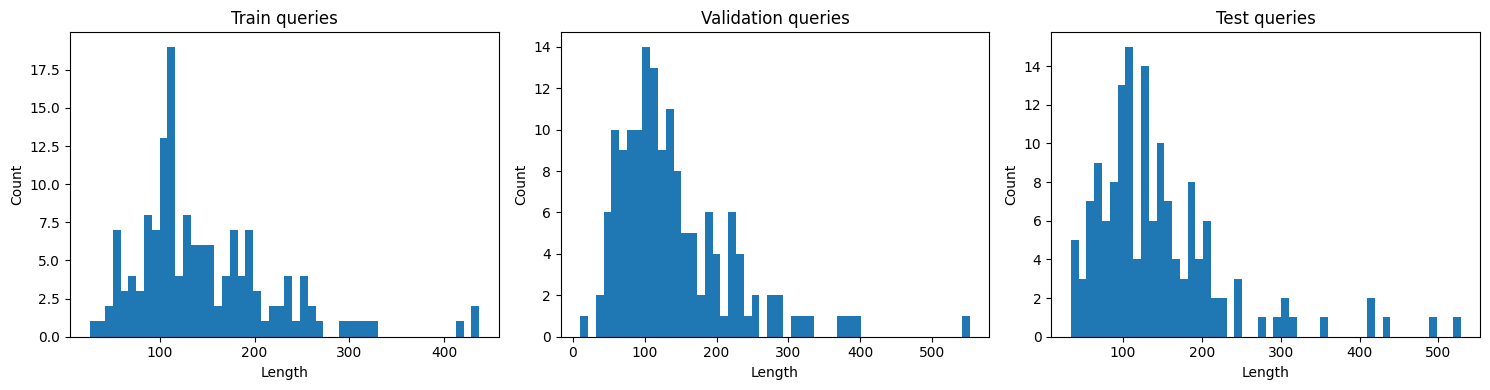

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# query length
train_queries_df["query_length"]=train_queries_df["query"].str.split().str.len()
val_queries_df["query_length"]=val_queries_df["query"].str.split().str.len()
test_queries_df["query_length"]=test_queries_df["query"].str.split().str.len()

fig,axes=plt.subplots(1,3,figsize=(15,4))

# train
axes[0].hist(train_queries_df["query_length"],bins=50)
axes[0].set_title("Train queries")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")

# validation
axes[1].hist(val_queries_df["query_length"],bins=50)
axes[1].set_title("Validation queries")
axes[1].set_xlabel("Length")
axes[1].set_ylabel("Count")

# test
axes[2].hist(test_queries_df["query_length"],bins=50)
axes[2].set_title("Test queries")
axes[2].set_xlabel("Length")
axes[2].set_ylabel("Count")

plt.tight_layout()

# save plot for GitHub
save_path = "reports/figures/query_length_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# download to computer
try:
    from google.colab import files as colab_files
    colab_files.download(save_path)
except Exception:
    print("Plot saved at:", save_path)

The distributions are similar across all splits. Most queries fall within a medium length range, but some queries are significantly longer. This suggests that semantic models such as SBERT and MonoT5 may have an advantage over lexical models like BM25 for capturing contextual meaning.Since semantic models capture contextual meaning and are therefore more effective for handling descrptive queries. Their distributions are similar.

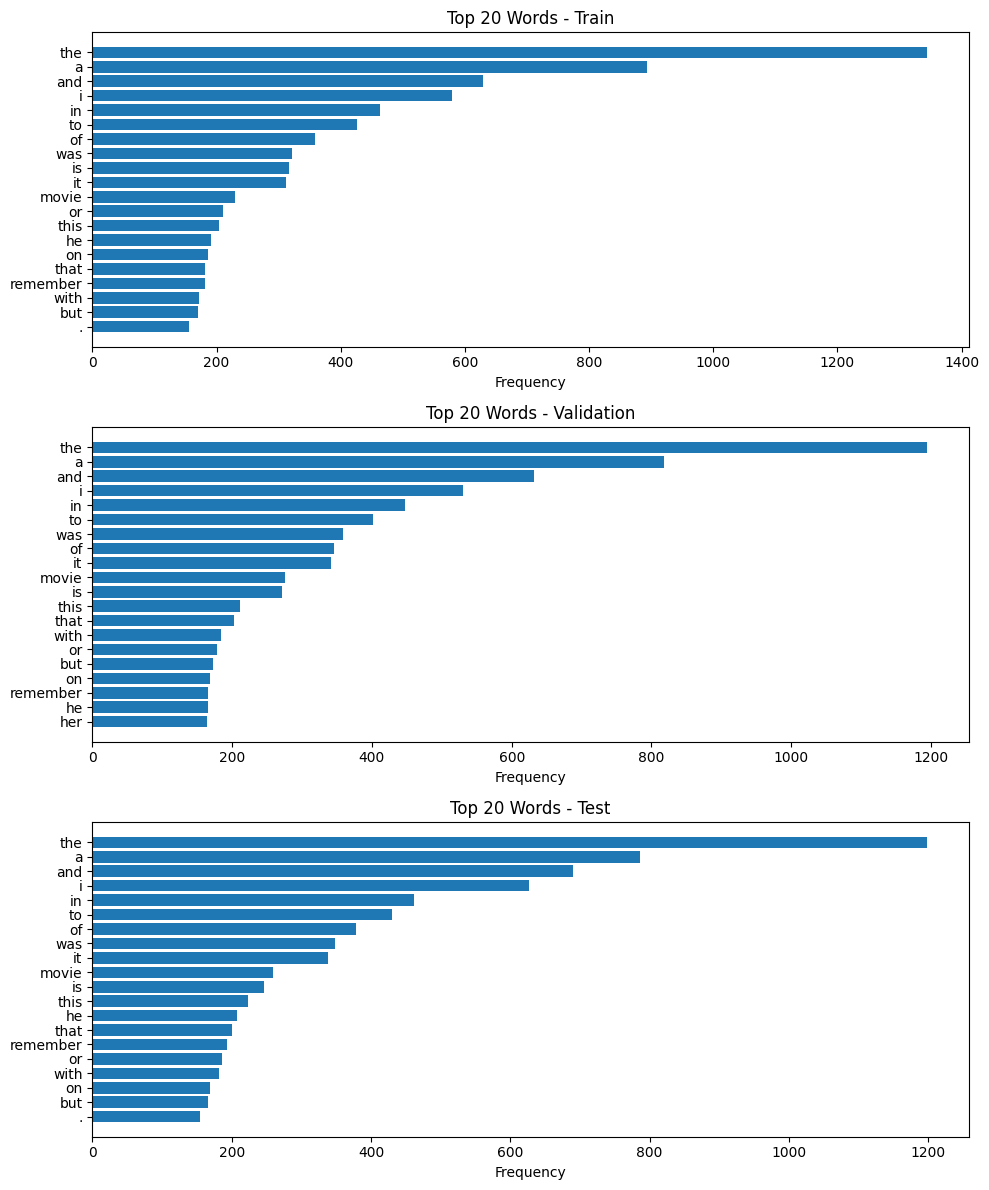

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

os.makedirs("reports/figures", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# train
all_words = " ".join(queries_train_2024["query"]).lower().split()
word_counts = Counter(all_words)
top_words = dict(word_counts.most_common(20))

axes[0].barh(list(top_words.keys()), list(top_words.values()))
axes[0].set_title("Top 20 Words - Train")
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

# val
all_words = " ".join(queries_val_2024["query"]).lower().split()
word_counts = Counter(all_words)
top_words = dict(word_counts.most_common(20))

axes[1].barh(list(top_words.keys()), list(top_words.values()))
axes[1].set_title("Top 20 Words - Validation")
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

# test
all_words = " ".join(queries_test_2024["query"]).lower().split()
word_counts = Counter(all_words)
top_words = dict(word_counts.most_common(20))

axes[2].barh(list(top_words.keys()), list(top_words.values()))
axes[2].set_title("Top 20 Words - Test")
axes[2].set_xlabel("Frequency")
axes[2].invert_yaxis()

# layout
plt.tight_layout()

# save plot
save_path = "reports/figures/top20_words_closed_words_splits.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

# download
try:
    from google.colab import files as colab_files
    colab_files.download(save_path)
except:
    print("Plot saved at:", save_path)

This plot shows that the most frequent words in the queries are closed-class words such as “the,” “and,” and “to.” The word “movie” also appears frequently, indicating that the dataset is mainly focused on the movie domain. Additionally, words like “I,” “was,” “he,” and “it” suggest that many queries are written from personal memory. Generally test, validation and train have same common words. These are closed class words so also I want to see open class words.

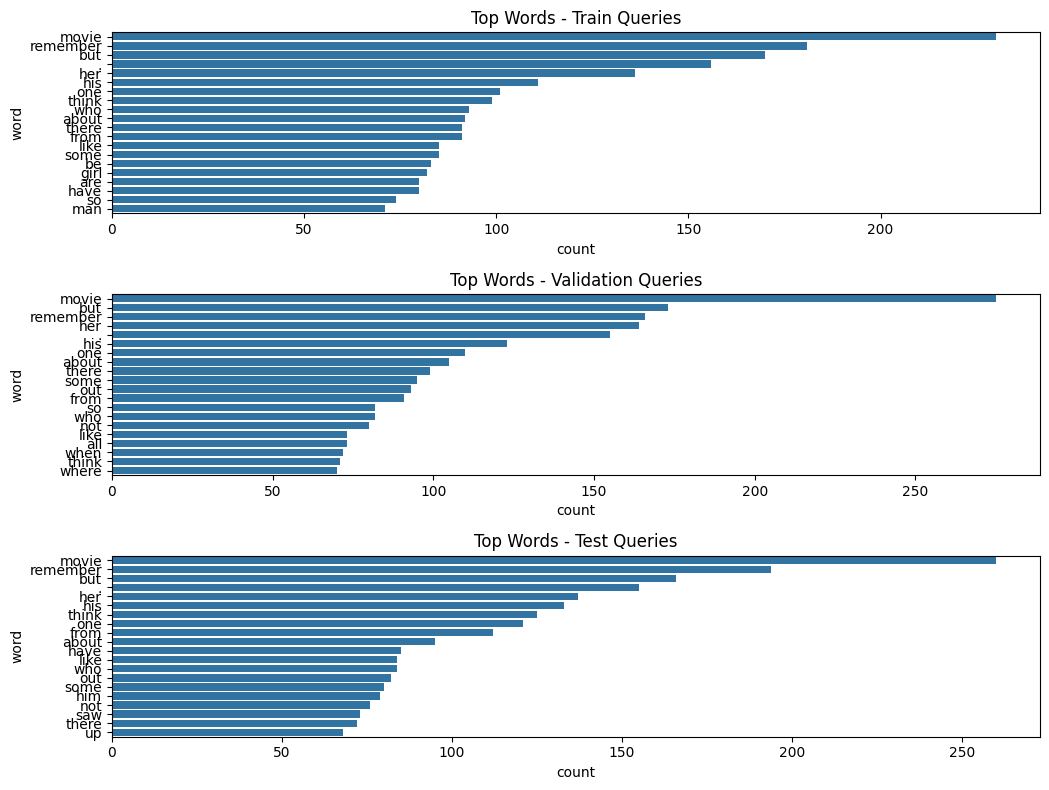

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# after removing closed words, we try to find out most
# appearing words.

# cleaning tokenizer
def clean_and_tokenize(text):
    text = str(text).lower()
    re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()

    stopwords = set([
        "the","a","an","and","or","in","on","at","to","of","is","it",
        "this","that","was","for","with","as","by","he","she","they",
        "we","you","i"
    ])

    tokens = [t for t in tokens if t not in stopwords]
    return tokens


def get_top_words(df):
    tokens = []
    for text in df["query"]:
        tokens.extend(clean_and_tokenize(text))
    counts = Counter(tokens)
    return counts.most_common(20)


train_top = get_top_words(queries_train_2024)
val_top   = get_top_words(queries_val_2024)
test_top  = get_top_words(queries_test_2024)

train_words_df = pd.DataFrame(train_top, columns=["word", "count"])
val_words_df   = pd.DataFrame(val_top, columns=["word", "count"])
test_words_df  = pd.DataFrame(test_top, columns=["word", "count"])

fig, axes = plt.subplots(3, 1, figsize=(10.6, 8))

sns.barplot(data=train_words_df, x="count", y="word", ax=axes[0])
axes[0].set_title("Top Words - Train Queries")

sns.barplot(data=val_words_df, x="count", y="word", ax=axes[1])
axes[1].set_title("Top Words - Validation Queries")

sns.barplot(data=test_words_df, x="count", y="word", ax=axes[2])
axes[2].set_title("Top Words - Test Queries")

plt.tight_layout()

# save plot for GitHub
save_path = "reports/figures/top20_with_open_words_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# download to your computer if running in Colab
try:
    from google.colab import files as colab_files
    colab_files.download(save_path)
except Exception:
    print("Plot saved at:", save_path)

The most frequent words are similar across the train, validation, and test sets. Words such as “movie”, “remember”, and “think” appear consistently across all splits. In particular, “movie” is the most frequent word, confirming that the dataset is strongly focused on the movie domain.

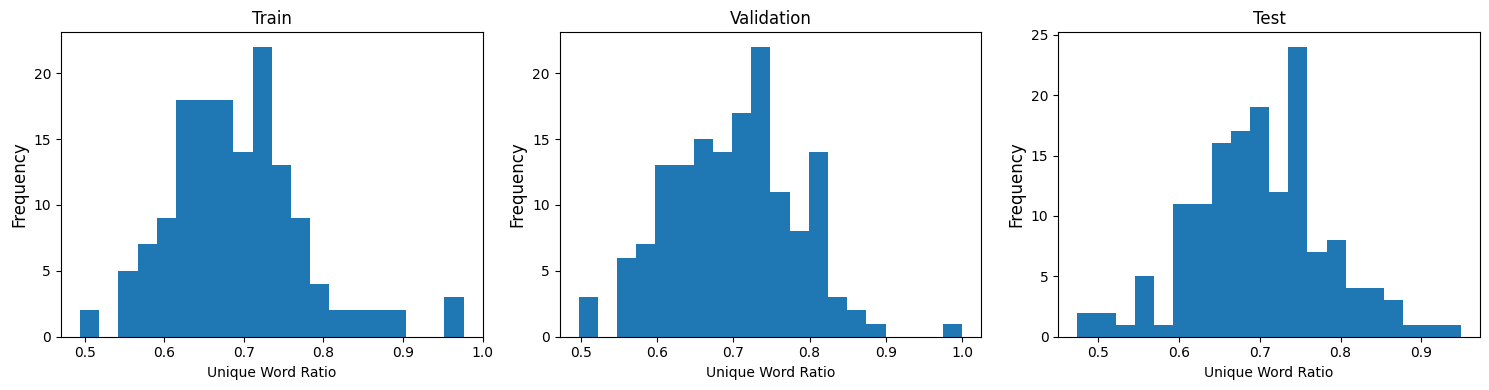

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# unique word count
queries_train_2024["unique_ratio"] = (
    queries_train_2024["query"].str.split().apply(set).str.len()
    / queries_train_2024["query"].str.split().str.len()
)

queries_val_2024["unique_ratio"] = (
    queries_val_2024["query"].str.split().apply(set).str.len()
    / queries_val_2024["query"].str.split().str.len()
)

queries_test_2024["unique_ratio"] = (
    queries_test_2024["query"].str.split().apply(set).str.len()
    / queries_test_2024["query"].str.split().str.len()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(queries_train_2024["unique_ratio"], bins=20)
axes[0].set_title("Train")
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_xlabel("Unique Word Ratio", fontsize=10)

axes[1].hist(queries_val_2024["unique_ratio"], bins=20)
axes[1].set_title("Validation")
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_xlabel("Unique Word Ratio", fontsize=10)

axes[2].hist(queries_test_2024["unique_ratio"], bins=20)
axes[2].set_title("Test")
axes[2].set_ylabel("Frequency", fontsize=12)
axes[2].set_xlabel("Unique Word Ratio", fontsize=10)

plt.tight_layout()

# save plot for GitHub
save_path = "reports/figures/unique_words_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# download
try:
    from google.colab import files as colab_files
    colab_files.download(save_path)
except Exception:
    print("Plot saved at:", save_path)

The relatively high unique-word ratio suggests that many queries are descriptive and lexically varied. This may make exact lexical matching harder and motivates the use of semantic retrieval models in addition to lexical baselines.

In [ ]:
# Semantic similarity between models by using SBERT model
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"

warnings.filterwarnings("ignore")

# loading pre-trained model
with io.capture_output():
    model = SentenceTransformer("all-MiniLM-L6-v2")

# TRAIN
embeddings = model.encode(
    queries_train_2024["query"].tolist(),
    show_progress_bar=False
)
sim = cosine_similarity(embeddings)
mask = ~np.eye(sim.shape[0], dtype=bool)
avg_sim = sim[mask].mean()
print("Train average similarity:", avg_sim)
print("Train std:", sim[mask].std())
print("Train min:", sim[mask].min())
print("Train max:", sim[mask].max())

# TEST
embeddings = model.encode(
    queries_test_2024["query"].tolist(),
    show_progress_bar=False
)
sim = cosine_similarity(embeddings)
mask = ~np.eye(sim.shape[0], dtype=bool)
avg_sim = sim[mask].mean()
print("Test average similarity:", avg_sim)
print("Test std:", sim[mask].std())
print("Test min:", sim[mask].min())
print("Test max:", sim[mask].max())


# VALIDATION
embeddings = model.encode(
    queries_val_2024["query"].tolist(),
    show_progress_bar=False
)
sim = cosine_similarity(embeddings)
mask = ~np.eye(sim.shape[0], dtype=bool)
avg_sim = sim[mask].mean()
print("Validation average similarity:", avg_sim)
print("Validation std:", sim[mask].std())
print("Validation min:", sim[mask].min())
print("Validation max:", sim[mask].max())

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train average similarity: 0.3577144
Train std: 0.09735512
Train min: 0.010107547
Train max: 0.71786535
Test average similarity: 0.3705784
Test std: 0.10075205
Test min: 0.011242714
Test max: 0.7247617
Validation average similarity: 0.37170848
Validation std: 0.09737604
Validation min: -0.007872374
Validation max: 0.7021101


The similarity values are not too high, indicating that queries are not duplicates but still share some semantic overlap. This confirms that the dataset is diverse while remaining within the same domain.

The standard deviation is moderate (~0.09–0.10), indicating a reasonable spread in similarities.

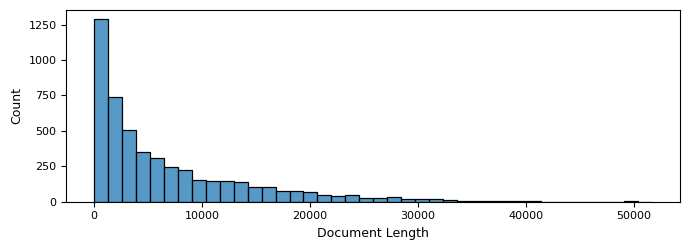

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# corpus length distribution
# sample corpus is used only for EDA, not for retrieval experiments
corpus_df=list(islice(corpus_2024.docs_iter(),5000))
corpus_df=pd.DataFrame(corpus_df)
corpus_df["doc_len"] = corpus_df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 2.6))

sns.histplot(corpus_df["doc_len"], bins=40)
plt.xlabel("Document Length", fontsize=9)
plt.ylabel("Count", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

# save plot for GitHub
save_path = "reports/figures/corpus_length_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# download
try:
    from google.colab import files as colab_files
    colab_files.download(save_path)
except Exception:
    print("Plot saved at:", save_path)

Due to the large corpus size (3M+ documents), we analyze a sampled subset for efficiency.

The distribution of corpus length is right-skewed. Most of the documents are of relatively short length, while some of the documents are of extremely long length.

The long tail of the distribution also tells us that there are some outliers in the data.

In [ ]:
# finding vocabulary size
all_words = " ".join(train_queries_df["query"]).lower().split()
print("Vocabulary size for train:", len(set(all_words)))

all_words = " ".join(test_queries_df["query"]).lower().split()
print("Vocabulary size for test:", len(set(all_words)))

all_words = " ".join(val_queries_df["query"]).lower().split()
print("Vocabulary size for validation:", len(set(all_words)))

Vocabulary size for train: 4344
Vocabulary size for test: 4154
Vocabulary size for validation: 4094


Vocabulary size is similar across all splits. Train is slightly higher, but overall distributions are consistent. This shows queries are diverse and not repetitive.

In [ ]:
# relevance distribution
print(qrels_train_2024["relevance"].value_counts())
print(qrels_test_2024["relevance"].value_counts())
print(qrels_val_2024["relevance"].value_counts())

# Each query is associated with exactly one relevant
# document, resulting in a one-to-one mapping.
# This simplifies evaluation but makes ranking
# performance more sensitive.

relevance
1    150
Name: count, dtype: int64
relevance
1    150
Name: count, dtype: int64
relevance
1    150
Name: count, dtype: int64


In [ ]:
print("Train mean query length:", train_queries_df["query_length"].mean())
print("Train std query length:", train_queries_df["query_length"].std())

print("Validation mean:", val_queries_df["query_length"].mean())
print("Validation std query length:", val_queries_df["query_length"].std())

print("Test mean:", test_queries_df["query_length"].mean())
print("Test std query length:", test_queries_df["query_length"].std())

Train mean query length: 147.38
Train std query length: 74.9965251991471
Validation mean: 139.32666666666665
Validation std query length: 80.26662755393072
Test mean: 144.3
Test std query length: 84.59407614083149


The average query length is relatively high across all splits. This indicates that queries are generally long and descriptive rather than short keyword-based inputs.

The large standard deviation suggests that query lengths vary significantly across users. For example, some users provide detailed descriptions, while others submit shorter queries.

In [ ]:
print("Mean doc length:", corpus_df["doc_len"].mean())
print("Median doc length:", corpus_df["doc_len"].median())

Mean doc length: 6745.2912
Median doc length: 3793.5


The mean document length (6745) is significantly higher than the median document length (3793). This indicates that the distribution is right-skewed, with a long tail of very large documents.

In [ ]:
# number of queries
num_train_q = len(train_queries_df)
num_val_q   = len(val_queries_df)
num_test_q  = len(test_queries_df)

# number of qrels
num_train_rel = len(train_qrels_df)
num_val_rel   = len(val_qrels_df)
num_test_rel  = len(test_qrels_df)


# query length stats
train_lengths = train_queries_df["query"].str.split().str.len()
val_lengths   = val_queries_df["query"].str.split().str.len()
test_lengths  = test_queries_df["query"].str.split().str.len()

# table

summary_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Num Queries": [num_train_q, num_val_q, num_test_q],
    "Num Qrels": [num_train_rel, num_val_rel, num_test_rel],
    "Avg Query Length": [
        train_lengths.mean(),
        val_lengths.mean(),
        test_lengths.mean()
    ],
    "Median Query Length": [
        train_lengths.median(),
        val_lengths.median(),
        test_lengths.median()
    ]
})


display(summary_df)

,Split,Num Queries,Num Qrels,Avg Query Length,Median Query Length
0,Train,150,150,147.380000,127.0
1,Validation,150,150,139.326667,118.5
2,Test,150,150,144.300000,125.5


From the table above, we can see that the number of queries and qrels is evenly distributed across all splits. The average and median query length are similar as well.

In [ ]:
# basic quality checks

print("Missing values in queries (train):", train_queries_df.isnull().sum().sum())
print("Duplicate queries (train):", train_queries_df["query"].duplicated().sum())

print("Missing values in qrels (train):", train_qrels_df.isnull().sum().sum())
print("Duplicate qrels (train):", train_qrels_df.duplicated().sum())

Missing values in queries (train): 0
Duplicate queries (train): 0
Missing values in qrels (train): 0
Duplicate qrels (train): 0


In [ ]:
print("Missing values in queries (validation):", val_queries_df.isnull().sum().sum())
print("Duplicate queries (validation):", val_queries_df["query"].duplicated().sum())

print("Missing values in qrels (validation):", val_qrels_df.isnull().sum().sum())
print("Duplicate qrels (validation):", val_qrels_df.duplicated().sum())

Missing values in queries (validation): 0
Duplicate queries (validation): 0
Missing values in qrels (validation): 0
Duplicate qrels (validation): 0


In [ ]:
print("Missing values in queries (test):", test_queries_df.isnull().sum().sum())
print("Duplicate queries (test):", test_queries_df["query"].duplicated().sum())

print("Missing values in qrels (test):", test_qrels_df.isnull().sum().sum())
print("Duplicate qrels (test):", test_qrels_df.duplicated().sum())

Missing values in queries (test): 0
Duplicate queries (test): 0
Missing values in qrels (test): 0
Duplicate qrels (test): 0


Data is clean: no missing values or duplicates in queries and qrels (train, validation, test).

# PRE-PROCESSING STEP

We apply light preprocessing for lexical models (BM25), while keeping raw text for semantic models (SBERT, MonoT5) to preserve contextual meaning. We need to preprocess corpus and queries, not for qrels.

In [ ]:
# for corpus pre-processing
# light custom stopword filtering for lexical retrieval preprocessing

def preprocess_bm25(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)   # safe version
    tokens = text.split()

    stopwords = {
        "the","a","an","and","or","in","on","at","to","of","is","it",
        "this","that","was","for","with","as","by"
    }

    tokens = [t for t in tokens if t not in stopwords]
    return tokens

In [ ]:
# raw text (for SBERT and MonoT5)
corpus_df["text_raw"]=corpus_df["text"]

# cleaned text (for BM25)
corpus_df["text_cleaned"]=corpus_df["text"].apply(preprocess_bm25)

In [ ]:
# for queries
train_queries_df["query_raw"]=train_queries_df["query"]
val_queries_df["query_raw"]=val_queries_df["query"]
test_queries_df["query_raw"]=test_queries_df["query"]

train_queries_df["query_clean"]=train_queries_df["query"].apply(preprocess_bm25)
val_queries_df["query_clean"]=val_queries_df["query"].apply(preprocess_bm25)
test_queries_df["query_clean"]=test_queries_df["query"].apply(preprocess_bm25)